# Arbeitsblatt 1

In [2]:
#Imports der benötigten Pakete
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Einlesen der CSV-Datei
data = pd.read_csv('DABI2_Projekt1.csv')
data


,Unnamed: 0,rate,DateTime,KWH,meters
0,0,Std,2011-11-23 09:00:00.0000000,0.355,1
1,1,Std,2011-11-23 09:30:00.0000000,0.414,1
2,2,Std,2011-11-23 10:00:00.0000000,0.698,4
3,3,Std,2011-11-23 10:30:00.0000000,0.455,4
4,4,Std,2011-11-23 11:00:00.0000000,0.670,5
...,...,...,...,...,...
80685,80685,ToU,2014-02-27 22:00:00.0000000,302.767,1026
80686,80686,ToU,2014-02-27 22:30:00.0000000,286.752,1026
80687,80687,ToU,2014-02-27 23:00:00.0000000,254.521,1026
80688,80688,ToU,2014-02-27 23:30:00.0000000,211.434,1026


In [3]:
# Erster Blick auf die Daten
data.head()
#Daten bereinigen und in das richtige Format bringen
data['DateTime'] = pd.to_datetime(data['DateTime'], format='mixed')


# Aufgabe 1: 
Prüfen Sie den Energieverbrauch auf Trends und Periodizität, trennen Sie die verschiedenen Bestandteile und visualisieren Sie sie geeigneter Weise.

Text(0.5, 1.0, 'Gesamtenergieverbrauch über die Zeit')

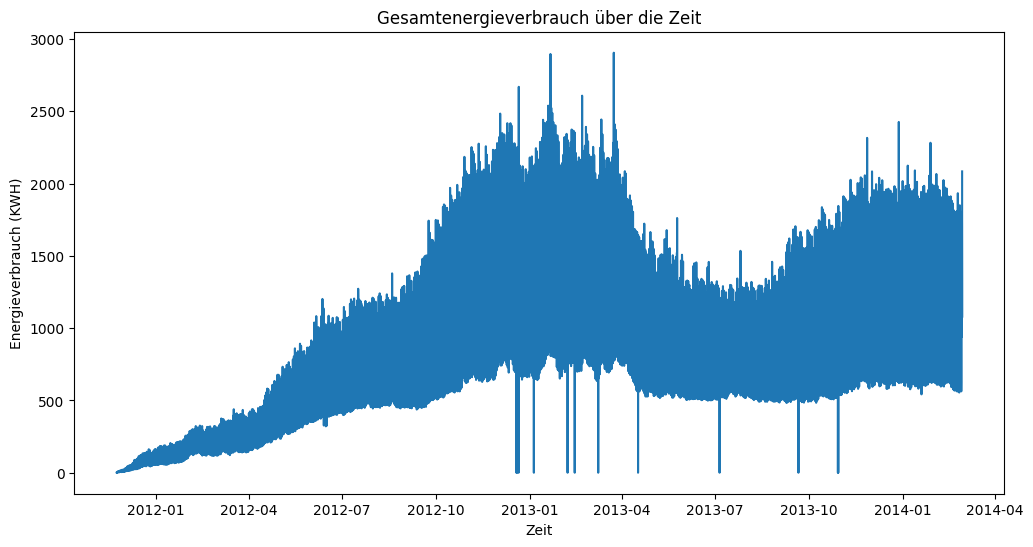

In [4]:
#Visualisierung des Energieverbrauchs über die Zeit
data_total = data.groupby('DateTime')['KWH'].sum()
plt.figure(figsize=(12, 6))
plt.plot(data_total)
plt.xlabel("Zeit")
plt.ylabel("Energieverbrauch (KWH)")
plt.title("Gesamtenergieverbrauch über die Zeit")

### Interpretation 
Die Zeitreihe zeigt einen insgesamt steigenden Energieverbrauch im Jahr 2012, der Anfang 2013 seinen Höhepunkt erreicht. Anschließend ist ein deutlicher Rückgang zu erkennen, bevor der Verbrauch im weiteren Verlauf wieder moderat ansteigt. Über den gesamten Zeitraum hinweg sind starke kurzfristige Schwankungen sichtbar, was auf eine ausgeprägte periodische Struktur hindeutet. Diese regelmäßigen Schwankungen lassen sich plausibel durch tägliche Verbrauchsmuster erklären. Zudem treten einzelne starke Einbrüche im Verbrauch auf, die auf Ausreißer oder Messfehler hindeuten könnten. Insgesamt weist die Zeitreihe sowohl einen klaren Trend als auch saisonale Effekte auf und ist daher nicht stationär. Eine Zerlegung in Trend, saisonale Komponenten und Residuen ist notwendig, um diese unterschiedlichen Einflüsse getrennt zu analysieren und die Zeitreihe besser modellieren zu können.

In [5]:
#Zeitstempel als Index setzen
data.reset_index(inplace=True)
data.set_index('DateTime', inplace=True)

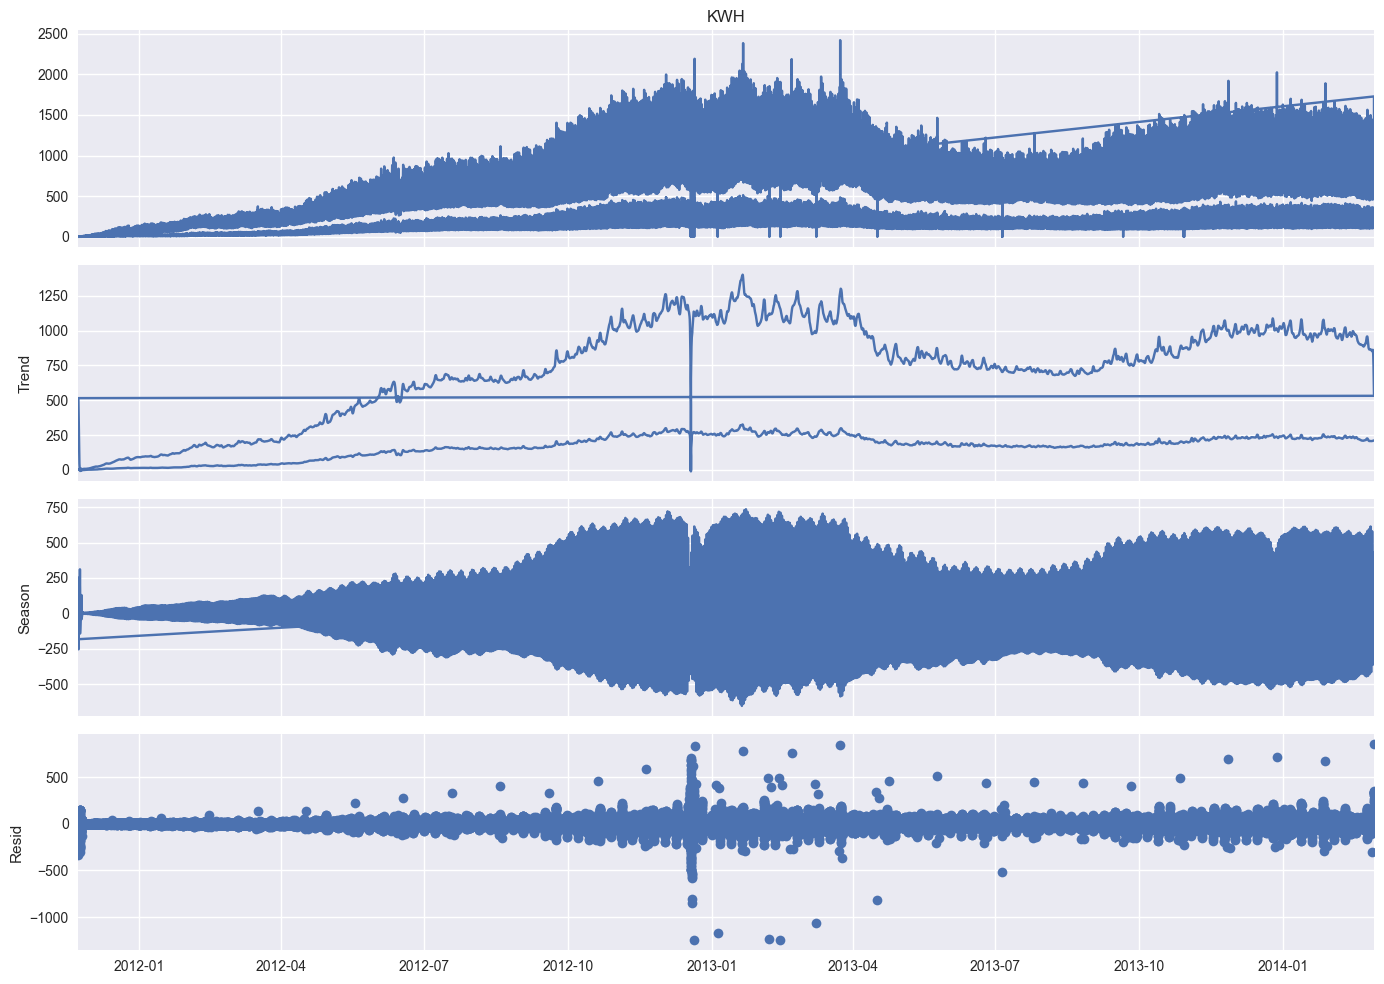

In [7]:
#STL- Zerlegung durchführen um periodische Muster und Trends zu identifizieren
from statsmodels.tsa.seasonal import STL
stl= STL(data["KWH"],period=48) #period=48 für halbstündliche Muster
result = stl.fit()

result.trend
result.seasonal
result.resid

#Visualisierung der Bestandteile
plt.style.use("seaborn-v0_8")
plt.rcParams.update({'font.size': 12})

fig = result.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

### 1.  Originalzeitreihe (KWH, oberer Plot)

Im oberen Plot ist der gesamte Energieverbrauch über die Zeit dargestellt. Es ist ein deutlicher langfristiger Trend erkennbar: ein Anstieg im Jahr 2012, ein Peak Anfang 2013 und anschließend ein Rückgang mit erneutem leichten Anstieg. Zusätzlich sind starke kurzfristige Schwankungen sichtbar, die auf regelmäßige Verbrauchsmuster hindeuten. Einzelne starke Einbrüche deuten auf Ausreißer oder mögliche Messfehler hin.

### 2.  Trendkomponente (Trend, zweiter Plot)

Die Trendkomponente zeigt den geglätteten langfristigen Verlauf des Energieverbrauchs. Kurzfristige Schwankungen werden hier herausgefiltert, sodass die grundlegende Entwicklung klar sichtbar wird. Man erkennt einen kontinuierlichen Anstieg bis Anfang 2013, gefolgt von einem Rückgang und einer späteren Stabilisierung. Der Trend verdeutlicht somit die übergeordnete Entwicklung der Nachfrage.

### 3.  Saisonale Komponente (Season, dritter Plot)

Dieser Plot zeigt die periodischen Schwankungen der Zeitreihe. Es ist ein regelmäßiges, sich wiederholendes Muster erkennbar, das typisch für den täglichen Energieverbrauch ist. Die Stärke der Schwankungen nimmt im Zeitverlauf zu, was darauf hindeutet, dass die saisonalen Effekte nicht konstant sind. Insgesamt bestätigt die Komponente eine klare tägliche Periodizität.

### 4.  Residuen (Resid, unterer Plot)

Die Residuen enthalten die verbleibenden Werte nach Entfernung von Trend und Saisonalität. Idealerweise sollten diese zufällig um null streuen, was hier nur teilweise der Fall ist. Es sind mehrere starke Ausreißer sowie Phasen mit erhöhter Streuung erkennbar, insbesondere um 2013. Dies deutet darauf hin, dass nicht alle Strukturen vollständig entfernt wurden und noch weitere Einflüsse in den Daten vorhanden sind.

# Aufgabe 2
Ermitteln Sie die Autokorrelationen und partiellen Autokorrelationen der Zeitreihe.

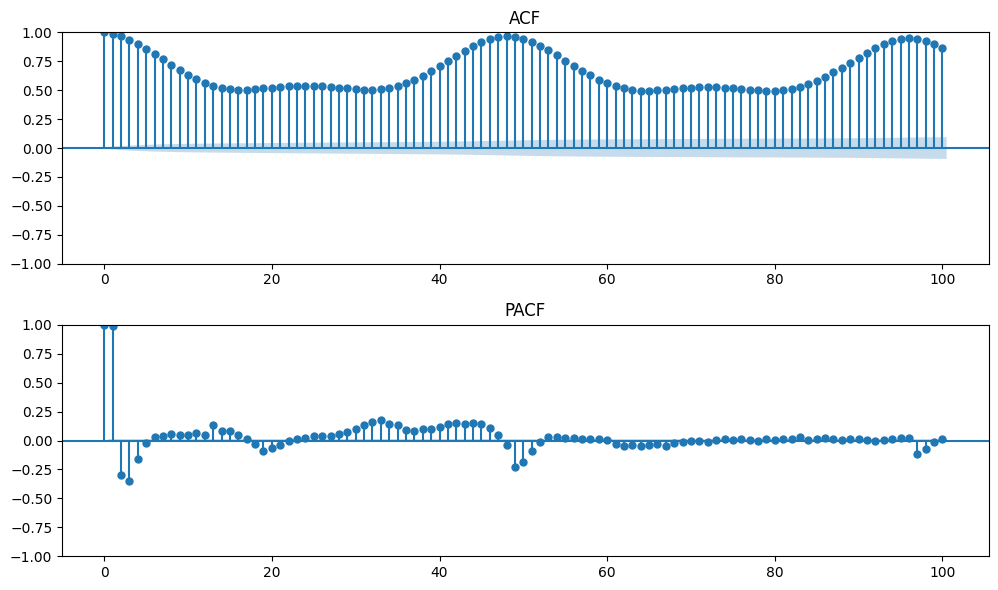

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ACF und PACF
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(data_total, lags=100, ax=axes[0])
axes[0].set_title("ACF")

plot_pacf(data_total, lags=100, ax=axes[1])
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()


### Interpretation
Die Autokorrelationsfunktion (ACF) zeigt über viele Lags hinweg hohe Werte und eine deutlich erkennbare wellenförmige Struktur. Besonders auffällig sind die regelmäßigen Peaks, insbesondere bei etwa Lag 48 und dessen Vielfachen, was auf eine ausgeprägte tägliche Periodizität in der Zeitreihe hinweist. Zudem fällt die Autokorrelation nur sehr langsam ab, was auf einen vorhandenen Trend und damit Nicht-Stationarität hindeutet.

Die partielle Autokorrelationsfunktion (PACF) zeigt einen starken Ausschlag bei Lag 1, was auf eine starke kurzfristige Abhängigkeit zwischen aufeinanderfolgenden Beobachtungen hinweist. Danach treten kleinere, aber strukturierte Ausschläge auf, insbesondere im Bereich der saisonalen Lags. Dies deutet darauf hin, dass neben kurzfristigen auch saisonale Einflüsse eine Rolle spielen.

Insgesamt bestätigen ACF und PACF, dass die Zeitreihe sowohl Trend- als auch saisonale Komponenten enthält und somit nicht stationär ist.

### Aufgabe 3: Überprüfung der Eliminierung trivialer Muster

Zur Beurteilung, ob die wesentlichen Muster der Zeitreihe durch die Zerlegung entfernt wurden, werden insbesondere die Residuen der STL-Zerlegung betrachtet. Idealerweise sollten diese keine systematischen Strukturen mehr aufweisen und sich wie weißes Rauschen verhalten.

Die ursprüngliche Zeitreihe zeigt eine ausgeprägte Autokorrelation sowie klare periodische Muster, insbesondere in Form regelmäßiger Peaks in der Autokorrelationsfunktion, was auf eine starke saisonale Komponente (z. B. tägliche Zyklen) hinweist.

Nach der Zerlegung wurden Trend und saisonale Effekte weitgehend isoliert. Die Analyse der Residuen zeigt jedoch weiterhin Auffälligkeiten, insbesondere in Form von Ausreißern und teilweise erhöhter Streuung. Dies deutet darauf hin, dass die Residuen nicht vollständig frei von Struktur sind.

Eine vollständige Eliminierung der trivialen Muster liegt somit nicht vor. Mögliche Gründe hierfür sind zusätzliche saisonale Effekte (z. B. wöchentliche Muster) oder nicht berücksichtigte Einflussfaktoren. Insgesamt lässt sich festhalten, dass die Zerlegung die wichtigsten Komponenten identifiziert, jedoch noch Reststrukturen in den Residuen verbleiben.

# Aufgabe 4

''' Erstellen Sie ein lineares Prognosemodell, das den Stromverbrauch jeweils 6
Stunden in die Zukunft prognostiziert. '''

In [ ]:
# target definieren
data["target"] = data["KWH"].shift(-12)

In [69]:
# Feature erstellen

data["lag_1"] = data["KWH"].shift(1)
data["lag_2"] = data["KWH"].shift(2)
data["lag_12"] = data["KWH"].shift(12)   # 6 Stunden zurück
data["lag_24"] = data["KWH"].shift(24)   # 1 Tag zurück
data["lag_48"] = data["KWH"].shift(48)
data["hour"] = data.index.hour
data["dayofweek"] = data.index.dayofweek
data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
data["rolling_mean_6"] = data["KWH"].shift(1).rolling(6).mean() #leichte Glättung der input daten

In [70]:
# missing values entfernen

data = data.dropna()

In [71]:
#train und test split erstellen

split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

In [ ]:
#features und target definieren

features = ["lag_1", "lag_2", "lag_12", "lag_24", "lag_48", "hour", "dayofweek", "is_weekend", "rolling_mean_6"]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

In [79]:
# lineares Modell trainieren

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
# Vorhersage machen

y_pred = model.predict(X_test)

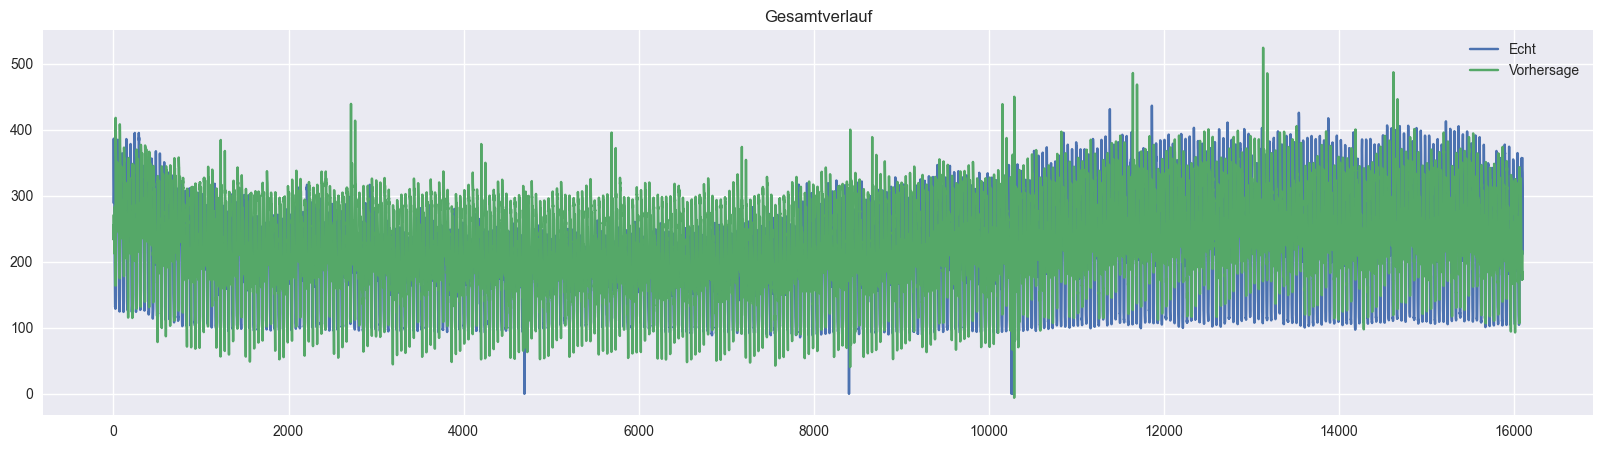

In [81]:
# Visualisiserung

plt.figure(figsize=(20,5))

plt.plot(y_test.values, label="Echt")
plt.plot(y_pred, label="Vorhersage")

plt.title("Gesamtverlauf")
plt.legend()

plt.show()

# Aufgabe 5

In [82]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

-0.6179505446527764


-> negativ, Modell macht die Vorhersage noch schlechter als der Mittelwert

In [ ]:
#Zeitreihe zerlegen

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(data["KWH"], model="additive", period=48)

In [50]:
total_var = data["KWH"].var()

trend_var = result.trend.var()
seasonal_var = result.seasonal.var()
resid_var = result.resid.var()

In [51]:
print("Trend Anteil:", trend_var / total_var)
print("Saisonalität Anteil:", seasonal_var / total_var)
print("Rest:", resid_var / total_var)

Trend Anteil: 0.8131353947241157
Saisonalität Anteil: 0.04308557625581624
Rest: 0.14287645461551665


3 bestandteile einer Zeitreihe
- Trend -> langfristige Richtung
- Saisonalität -> wiederkehrende Muster
- Rest -> alles andere

# Aufgabe 6

### Der Stromversorger will beurteilen, welche Auswirkungen die zeitabhängigen Tarife haben. Untersuchen Sie, ob Sie interessante Unterschiede im Verbrauchsverhalten zwischen den Tarifen feststellen können. 

In [ ]:
# daten trennen

std = data[data["rate"] == "Std"]
tou = data[data["rate"] == "ToU"]

In [ ]:
# durchschnittsverbrauch

std_mean = std["KWH"].mean()
tou_mean = tou["KWH"].mean()

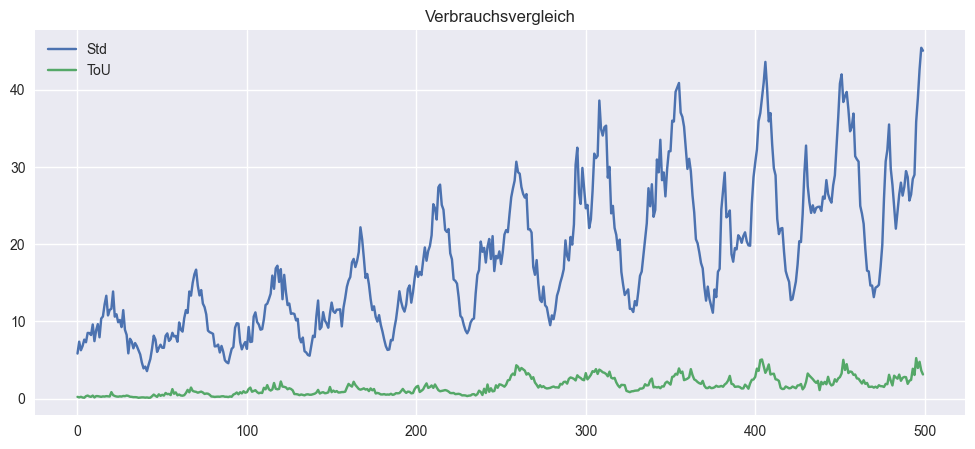

In [86]:
plt.figure(figsize=(12,5))
plt.plot(std["KWH"].values[:500], label="Std")
plt.plot(tou["KWH"].values[:500], label="ToU")
plt.legend()
plt.title("Verbrauchsvergleich")
plt.show()

In [ ]:
# Verhalten nach Uhrzeit vergleichen

std_hour = std.groupby(std.index.hour)["KWH"].mean()
tou_hour = tou.groupby(tou.index.hour)["KWH"].mean()

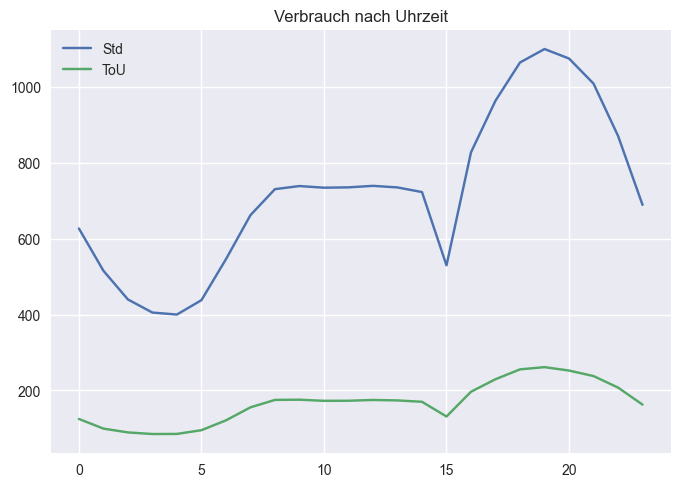

In [88]:
plt.plot(std_hour, label="Std")
plt.plot(tou_hour, label="ToU")
plt.legend()
plt.title("Verbrauch nach Uhrzeit")
plt.show()

Standardtarif deutlich höherer Gesamtverbrauch mit starker Tagesstruktu, inkl starkem Peak beim Feierabend

variabler Tarif mit weniger Verbrauch und gedämpftere Form


Erklärung Peak Unterschiede:
- ToU-Kunden reagieren teilweise auf Preissignale oder sind generell sparsamer.